In [11]:
library(tidyverse)
source("../scripts/00_R_presets.R")

# Figure 3: PoreC

Subplots:
- A) PoreC Read QC
- B) Dip3D phasing records
- C) PoreC TAD Scores or something
- D) Differential Loci
- E) X chromsome inactivation

In [12]:
# Subfigure sizes
sizes <- c(
    "A" = c(5,6),
    "B" = c(4,2)    # Dip3d QC
)

In [13]:
dt_dip3d <- read_tsv("../../analysis_other/dip3d/combined_dip3d_stats.tsv", show_col_types = FALSE)

colnames(dt_dip3d)

dt_dip3d <- dt_dip3d %>%
    mutate(unphased_frags = total_frags - h1_frags - h2_frags) %>%
    select(c("sample", "tag_type", "total_reads", "reads_with_phased_frags", "total_frags", "phased_frags", "unphased_frags", "h1_frags", "h2_frags")) %>%
    pivot_longer(!c(sample, tag_type))
head(dt_dip3d)

[1] "sample"                              "tag_type"                           
 [3] "total_reads"                         "reads_with_phased_frags"            
 [5] "reads_with_phased_frags_pct"         "total_frags"                        
 [7] "phased_frags"                        "phased_frags_pct"                   
 [9] "h1_frags"                            "h1_frags_pct"                       
[11] "h2_frags"                            "h2_frags_pct"                       
[13] "contacts_dist_2147483647_h1"         "contacts_dist_2147483647_h1_pct"    
[15] "contacts_dist_2147483647_h2"         "contacts_dist_2147483647_h2_pct"    
[17] "contacts_dist_2147483647_htrans"     "contacts_dist_2147483647_htrans_pct"
[19] "contacts_dist_2147483647_phased"     "contacts_dist_2147483647_phased_pct"
[21] "contacts_dist_2147483647_total"      "contacts_dist_50000000_h1"          
[23] "contacts_dist_50000000_h1_pct"       "contacts_dist_50000000_h2"          
[25] "contacts_dist_50000000_h2_pct"       "contacts_dist_50000000_htrans"      
[27] "contacts_dist_50000000_htrans_pct"   "contacts_dist_50000000_phased"      
[29] "contacts_dist_50000000_phased_pct"   "contacts_dist_50000000_total"       
[31] "contacts_dist_5000000_h1"            "contacts_dist_5000000_h1_pct"       
[33] "contacts_dist_5000000_h2"            "contacts_dist_5000000_h2_pct"       
[35] "contacts_dist_5000000_htrans"        "contacts_dist_5000000_htrans_pct"   
[37] "contacts_dist_5000000_phased"        "contacts_dist_5000000_phased_pct"   
[39] "contacts_dist_5000000_total"

sample,tag_type,name,value
<chr>,<chr>,<chr>,<dbl>
T2T00,imputed,total_reads,1294061033
T2T00,imputed,reads_with_phased_frags,600585645
T2T00,imputed,total_frags,9923540723
T2T00,imputed,phased_frags,4814562372
T2T00,imputed,unphased_frags,5108978351
T2T00,imputed,h1_frags,2412612423


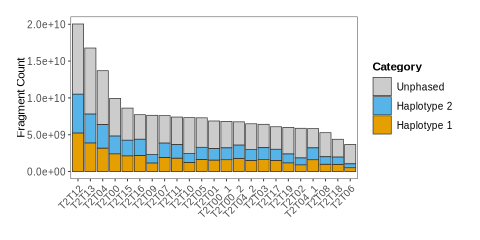

In [14]:
dt_dip3d_frags <- dt_dip3d %>%
     filter(name %in% c("unphased_frags", "h1_frags", "h2_frags")) %>%
     filter(tag_type == "imputed") %>%
     mutate( name = factor(name, levels = c("unphased_frags", "h2_frags", "h1_frags" )))

# Calculate total fragments per sample for sorting
sample_order <- dt_dip3d_frags %>%
    group_by(sample) %>%
    summarise(total = sum(value)) %>%
    arrange(desc(total)) %>%
    pull(sample)

dt_dip3d_frags <- dt_dip3d_frags %>%
    mutate(sample = factor(sample, levels = sample_order))

fig3_B_dip3d_stat <- ggplot(dt_dip3d_frags,
         aes(x = sample, y = value, fill = name)) +
    geom_bar(stat = "identity", position = "stack", col = "grey20", size = 0.2) +
    scale_fill_manual(values = c("h1_frags" = "#E69F00", 
                                  "h2_frags" = "#56B4E9", 
                                  "unphased_frags" = "grey80"),
                      labels = c("h1_frags" = "Haplotype 1", 
                                 "h2_frags" = "Haplotype 2", 
                                 "unphased_frags" = "Unphased")) +
    labs(x = element_blank(), y = "Fragment Count", fill = "Category") +
    theme(axis.text.x = element_text(angle = 45, hjust = 1)) +
    theme(panel.grid = element_blank())

ggsave("../../doc/figures/fig3_B_dip3d_stat.png", fig3_B_dip3d_stat, width = sizes["B1"] , height = sizes["B2"])
ggsave("../../doc/figures/fig3_B_dip3d_stat.pdf", fig3_B_dip3d_stat, width = sizes["B1"] , height = sizes["B2"])

options(repr.plot.width = sizes["B1"], repr.plot.height = sizes["B2"])
fig3_B_dip3d_stat